# Домашнее задание: Проектирование ИИ-агента на базе LLM

В этом домашнем задании вы пройдете путь от создания базового агента с кастомными инструментами до разработки защищенной мультиагентной системы с человеком в контуре (human-in-the-loop).

**Важное напоминание:** В рамках этого ДЗ вы можете использовать **любые технологии и фреймворки** для реализации задач. Однако мы настоятельно рекомендуем использовать **LangChain** для стандартной части и **LangGraph** для продвинутой - они дают удобные абстракции и хорошо документированы.

**Рекомендация по LLM:** Для отладки агентов со сложной логикой вызова инструментов рекомендуем начинать с больших моделей через [OpenRouter](https://openrouter.ai/) или любой другой сервис (к примеру гигачат, яндекс облако).
---

## Структура ДЗ (100 баллов)

| Часть | Подзадание | Баллы |
|---|---|---|
| Стандартная | 1.1 - 1.3 Реализация 3 инструментов | 20 |
| Стандартная | 1.4 Промпт-инженерия и создание ReAct агента | 10 |
| Стандартная | 1.5 Тестирование базового агента | 10 |
| Стандартная | 1.6 Анализ рисков и идеи по улучшению | 10 |
| Продвинутая | 2.1 Переход на LangGraph | 10 |
| Продвинутая | 2.2 - 2.3 Оркестратор и субагенты | 15 |
| Продвинутая | 2.4 Human-in-the-loop | 10 |
| Продвинутая | 2.5 Финальное тестирование | 5 |
| Продвинутая | 2.6 Анализ рисков и идеи по улучшению | 10 |


---
## Установка зависимостей

Установите необходимые библиотеки. Если вы выбрали инструменты, требующие дополнительных пакетов (например, `yfinance` для курсов валют или `feedparser` для новостей), добавьте их сюда.


In [63]:
!pip install -qU langchain langchain-openai langchain-core langchain-community langgraph datasets matplotlib pandas requests feedparser yfinance langchain-groq

In [64]:

import os
import getpass
from langchain_groq import ChatGroq
from langgraph.prebuilt import create_react_agent

if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = getpass.getpass("api ключ: ")

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.0
)


---
# Часть 1. Стандартная (50 баллов)

В этой части вам нужно:
1. Выбрать и реализовать три инструмента из предложенного списка.
2. Написать системный промпт и создать ReAct агента.
3. Протестировать агента на разных запросах.
4. Проанализировать риски и предложить идеи по улучшению.


### 1.1 - 1.3 Реализация инструментов (20 баллов)

Выберите **три любых инструмента** из списка ниже и реализуйте их:

1. **Поиск по базе знаний** - загрузите датасет `data-silence/rus_news_classifier` с HuggingFace (около 70k коротких русских новостей, поля: `news` - текст, `labels` - категория). Реализуйте поиск по ключевым словам или TF-IDF.
2. **Калькулятор сложных процентов** - функция принимает начальную сумму, годовую ставку (%), срок в годах и частоту капитализации в год.
3. **Построение графиков** - принимает данные (или путь к CSV), строит график через Matplotlib, сохраняет в файл и возвращает путь к нему.
4. **Текущий курс валют** - через публичный API ЦБ РФ (`https://cbr.ru/scripts/XML_daily.asp`, без ключа) или через `yfinance`.
5. **Текущая погода** - через `wttr.in` (без ключа, например: `requests.get("https://wttr.in/Москва?format=j1")`).
6. **Последние новости** - парсинг RSS-ленты любого СМИ через `feedparser` (например, `https://lenta.ru/rss/news`).

**Подсказки по реализации инструментов в LangChain:**
- Используйте декоратор `@tool` из `langchain_core.tools`.
- Пишите подробные docstring - именно по ним LLM понимает, когда и как вызывать инструмент.
- Указывайте типы аргументов (type hints) - это помогает LLM правильно формировать вызов.
- Инструмент должен возвращать строку или что-то, что легко преобразуется в строку.
- Обрабатывайте исключения внутри инструмента и возвращайте понятное сообщение об ошибке.

Пример структуры инструмента:
```python
from langchain_core.tools import tool

@tool
def get_weather(city: str) -> str:
    """Возвращает текущую погоду в указанном городе.
    Используй этот инструмент, когда пользователь спрашивает о погоде.
    Args:
        city: Название города на русском или английском языке.
    """
    try:
        # ваша реализация
        pass
    except Exception as e:
        return f"Ошибка при получении погоды: {e}"
```


In [65]:
import requests
import yfinance as yf
from langchain_core.tools import tool
@tool
def get_weather(city: str) -> str:
    """Возвращает текущую погоду в указанном городе.
    Используй этот инструмент, когда пользователь спрашивает о погоде, температуре или климате в конкретном городе.

    Args:
        city: Название города на русском или английском языке (например, "Москва", "London").
    """
    try:
        import urllib.parse
        encoded_city = urllib.parse.quote(city)
        response = requests.get(f"https://wttr.in/{encoded_city}?format=%C, %t", timeout=5)
        response.raise_for_status()
        return f"Погода в городе {city}: {response.text.strip()}"
    except Exception as e:
        return f"Ошибка при получении погоды для города '{city}': {str(e)}"


In [66]:
# TODO: Реализуйте Инструмент 2

@tool
def get_currency_rate(currency: str) -> str:
    """Возвращает текущий курс указанной валюты к российскому рублю (RUB).
    Используй этот инструмент, когда пользователь спрашивает о курсе доллара, евро или другой валюты к рублю.

    Args:
        currency: Код валюты в международном формате (например, "USD", "EUR", "CNY").
    """
    try:
        ticker = f"{currency}RUB=X"
        data = yf.Ticker(ticker)
        hist = data.history(period="1d")

        if hist.empty:
            return f"Не удалось найти курс для валюты {currency}. Проверьте код валюты (например, USD, EUR)."

        current_rate = hist['Close'].iloc[0]
        return f"Текущий курс {currency} к RUB составляет: {current_rate:.2f} рублей."
    except Exception as e:
        return f"Ошибка при получении курса валюты '{currency}': {str(e)}"


In [67]:
# TODO: Реализуйте Инструмент 3

@tool
def calculate_compound_interest(
    principal: float,
    rate: float,
    years: float,
    compounds_per_year: int = 1
) -> str:
    """Вычисляет итоговую сумму вклада или долга с учетом сложных процентов.
    Используй этот инструмент, когда пользователь просит рассчитать доход по вкладу, кредит или рост инвестиции с капитализацией.

    Args:
        principal: Начальная сумма (основной капитал) в рублях или другой валюте (число).
        rate: Годовая процентная ставка в процентах (например, 10 для 10%).
        years: Срок в годах (можно дробное число, например, 1.5).
        compounds_per_year: Частота капитализации в год (1 = ежегодно, 12 = ежемесячно, 4 = ежеквартально). По умолчанию 1.
    """
    try:
        if principal < 0 or rate < 0 or years < 0 or compounds_per_year <= 0:
            return "Ошибка: Все числовые параметры должны быть положительными, а частота капитализации больше нуля."

        r = rate / 100.0
        final_amount = principal * ((1 + r / compounds_per_year) ** (compounds_per_year * years))
        total_interest = final_amount - principal

        return (f"Результат расчета сложных процентов:\n"
                f"Начальная сумма: {principal:.2f}\n"
                f"Итоговая сумма: {final_amount:.2f}\n"
                f"Начисленные проценты: {total_interest:.2f}")
    except Exception as e:
        return f"Ошибка при расчете сложных процентов: {str(e)}"


In [68]:
tools = [get_weather, get_currency_rate, calculate_compound_interest]

### 1.4 Промпт-инженерия и создание ReAct агента (10 баллов)

**Задание:**
1. Напишите системный промпт для агента. Задайте ему персону (например, "опытный финансовый консультант" или "строгий корпоративный помощник").
2. Промпт должен явно запрещать агенту отвечать на вопросы, выходящие за рамки его инструментов - это защита от галлюцинаций.
3. Создайте ReAct агента с помощью LangChain и подключите к нему ваши инструменты.

**Подсказки:**
- В LangChain используйте `create_react_agent` из `langchain.agents` и `AgentExecutor`.
- Передайте системный промпт через `ChatPromptTemplate` или параметр `agent_kwargs`.
- Установите `verbose=True` в `AgentExecutor` - так вы будете видеть все промежуточные шаги (мысли агента, вызовы инструментов, ответы инструментов). Это очень полезно для отладки.
- Установите `handle_parsing_errors=True` - это защитит от падений при некорректном ответе LLM.
- Параметр `max_iterations` ограничивает количество шагов агента и защищает от бесконечных циклов.

Пример создания агента:
```python
from langchain.agents import create_react_agent, AgentExecutor
from langchain import hub
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="anthropic/claude-3.5-sonnet", ...)
tools = [tool_1, tool_2, tool_3]

# Можно взять готовый промпт из hub или написать свой
prompt = hub.pull("hwchase17/react")

agent = create_react_agent(llm, tools, prompt)
agent_executor = AgentExecutor(
    agent=agent,
    tools=tools,
    verbose=True,
    handle_parsing_errors=True,
    max_iterations=10
)
```


In [69]:
import os
import getpass
from langgraph.prebuilt import create_react_agent
from langchain_openai import ChatOpenAI

system_prompt = """Вы — строгий, точный и профессиональный корпоративный аналитик и помощник.
В вашем распоряжении есть следующие инструменты:
- get_weather: для получения текущей погоды в городе.
- get_currency_rate: для получения текущего курса валюты к рублю.
- calculate_compound_interest: для расчета сложных процентов по вкладу или кредиту.

Строгие правила , нарушения недопустимы:
1. Используйте только предоставленные инструменты для получения фактов . Никогда не придумывайте данные, курсы валют или математические расчеты.
2. Если пользователь задает вопрос, который нельзя решить с помощью ваших инструментов (например, дать медицинский совет, рассказать историю или ответить на вопрос о политике), вы должны вежливо отказать .
   Используйте точную фразу: "Извините, как корпоративный аналитик, я могу помочь только с запросами о погоде, курсах валют и финансовых расчетах."
3. Всегда отвечайте на русском языке , кратко , структурировано и по делу.
"""
agent_executor = create_react_agent(
    model=llm,
    tools=tools,
    prompt=system_prompt
)


/tmp/ipykernel_2298/4117687966.py:18: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent_executor = create_react_agent(


### 1.5 Тестирование базового агента (10 баллов)

Протестируйте вашего агента на различных запросах. Покажите вывод промежуточных шагов.

Задайте минимум 3 запроса:
1. Запрос, требующий вызова только одного инструмента.
2. Сложный запрос, требующий вызова двух инструментов последовательно.
3. Провокационный запрос вне компетенции агента (проверка защиты от галлюцинаций).

**Подсказка:** Используйте `agent_executor.invoke({"input": "ваш запрос"})`. Вывод `verbose=True` покажет все шаги рассуждений.


In [70]:
from langchain_core.messages import HumanMessage

def run_test(test_name: str, query: str):
    print(f"{test_name}")
    print(f"Запрос пользователя:{query}")

    for step in agent_executor.stream(
        {"messages": [HumanMessage(content=query)]},
        stream_mode="updates"
    ):
        if "agent" in step:
            message = step["agent"]["messages"][-1]
            if message.tool_calls:
                for tool_call in message.tool_calls:
                    print(f"Вызываю инструмент: {tool_call['name']}")
                    print(f"Аргументы: {tool_call['args']}")
            elif message.content:
                print(f"Финальный ответ агента:")
                print(f"{message.content}")

        elif "tools" in step:
            for tool_message in step["tools"]["messages"]:
                print(f"Результат инструмента {tool_message.name}:")
                print(f"{tool_message.content}")



In [71]:
run_test(
    test_name="Один инструмент (Погода)",
    query="Какая сейчас погода в Чебоксарах?"
)

Один инструмент (Погода)
Запрос пользователя:Какая сейчас погода в Чебоксарах?
Вызываю инструмент: get_weather
Аргументы: {'city': 'Чебоксары'}
Результат инструмента get_weather:
Погода в городе Чебоксары: Sunny, +80°F
Финальный ответ агента:
Сейчас в Чебоксарах солнечно, температура воздуха +27°C.


In [72]:
run_test(
    test_name="Два инструмента последовательно (Валюта + Калькулятор)",
    query="Какой сейчас курс доллара? И если я положу 100 000 рублей под 12% годовых с ежемесячной капитализацией на 3 года, сколько я получу в итоге?"
)

Два инструмента последовательно (Валюта + Калькулятор)
Запрос пользователя:Какой сейчас курс доллара? И если я положу 100 000 рублей под 12% годовых с ежемесячной капитализацией на 3 года, сколько я получу в итоге?
Вызываю инструмент: get_currency_rate
Аргументы: {'currency': 'USD'}
Вызываю инструмент: calculate_compound_interest
Аргументы: {'compounds_per_year': 12, 'principal': 100000, 'rate': 12, 'years': 3}
Результат инструмента calculate_compound_interest:
Результат расчета сложных процентов:
Начальная сумма: 100000.00
Итоговая сумма: 143076.88
Начисленные проценты: 43076.88
Результат инструмента get_currency_rate:
Текущий курс USD к RUB составляет: 78.30 рублей.
Финальный ответ агента:
Текущий курс доллара составляет 78.30 рублей. Если вы положите 100 000 рублей под 12% годовых с ежемесячной капитализацией на 3 года, вы получите в итоге 143 076.88 рублей.


In [73]:
run_test(
    test_name="Провокационный вопрос",
    query="Придумай и напиши стих об ужасном настроении в духе Есенина"
)

Провокационный вопрос
Запрос пользователя:Придумай и напиши стих об ужасном настроении в духе Есенина
Финальный ответ агента:
Извините, как корпоративный аналитик, я могу помочь только с запросами о погоде, курсах валют и финансовых расчетах.


### 1.6 Анализ рисков и идеи по улучшению (10 баллов)

Это задание не оценивается в баллах, но является обязательным. Здесь вы должны проявить критическое мышление и осмыслить то, что построили.

**Задание:** Напишите развернутый анализ (минимум 300 слов) в ячейке ниже, ответив на следующие вопросы:

**Риски текущей реализации:**
- Какие ошибки может совершить ваш агент? Приведите конкретные примеры запросов, на которых он может сломаться или дать неверный ответ.
- Что произойдет, если один из внешних API (погода, курсы) будет недоступен? Как агент обработает эту ситуацию?
- Насколько надежен ваш системный промпт? Можно ли обойти его ограничения с помощью хитро сформулированного запроса (prompt injection)?
- Какие риски несет использование больших LLM через внешние API (задержки, стоимость, утечка данных)?

**Гипотезы по улучшению:**
- Как можно улучшить качество поиска в инструменте базы знаний? Что если заменить keyword-поиск на семантический (с эмбеддингами)?
- Как можно сделать агента более устойчивым к ошибкам инструментов? Например, добавить логику повторных попыток или fallback-инструменты.
- Что изменится, если заменить большую LLM на маленькую локальную модель? Какие задачи пострадают в первую очередь?
- Как можно добавить память агенту, чтобы он помнил контекст предыдущих разговоров?

**Идеи по расширению:**
- Какие еще инструменты было бы полезно добавить для вашего конкретного сценария использования?
- Как бы вы оценивали качество работы агента в продакшене? Какие метрики использовали бы?


**Ваш анализ:**
Риски текущей реализации
1. Ошибки в интерпретации: Агент может сделать неверное предположение при неоднозначных запросах (например , на вопрос "Какой сейчас курс?" он может по умолчанию выбрать USD, вместо того чтобы уточнить у пользователя).
2. Сбой внешних API: Вернет "Ошибка..." , если выдало ошибку
3. Уязвимость к Prompt Injection: Текущий системный промпт блокирует прямые атаки , но сложные атаки могут обойти ограничения, так как модель сначала выполнит задачу перевода, активируя запрещенное действие.
4. Риски внешних LLM: Использование сторонних API несет риски утечки конфиденциальных корпоративных финансовых данных , а также зависимости от доступности сервиса и возможных задержек сети .

Гипотезы по улучшению
1. **Улучшение поиска в БЗ:** Если бы использовался инструмент базы знаний, переход с keyword/TF-IDF поиска на семантический (Dense Retrieval) с использованием векторных эмбеддингов (например, BGE-M3 + FAISS) критически повысил бы релевантность, позволяя находить ответы по смыслу, а не по точному совпадению слов.
2. Устойчивость к ошибкам: Внедрение декоратора @retry внутри инструментов для автоматических повторных попыток при сбоях сети . Если API недоступен, агент должен явно сообщать об этом, а не пытаться угадать ответ.
3. Переход на малые локальные модели:*Замена большой LLM на локальную решит проблемы приватности и стоимости. Однако пострадают сложные рассуждения , качество следования строгому формату JSON при вызове инструментов и понимание сложных нюансов естественного языка.
4. Добавление памяти: Интеграция MemorySaver из LangGraph позволит сохранять состояние диалога по thread_id . Это даст агенту возможность помнить контекст предыдущих реплик .

Идеи по расширению
1. Новые инструменты: Для сценария финансового аналитика полезно добавить: получение исторических данных акций , калькулятор реальной доходности с учетом инфляции и парсер свежих финансовых новостей для контекстного анализа.
2. **Метрики качества в продакшене:**
   - Tool Call Success Rate: Процент успешных вызовов инструментов без ошибок парсинга.
   - Hallucination Rate: Оценка фактологической точности ответов с помощью паттерна "LLM-as-a-judge".
   - Latency: Среднее время полного цикла выполнения запроса (включая вызовы API).
   - Прямая обратная связь пользователей .


---
# Часть 2. Продвинутая (50 баллов)

В этой части вы переведете агента на рельсы LangGraph, добавите разделение ролей (Оркестратор и субагенты) и внедрите механизм безопасности (Human-in-the-loop).

**Напоминание:** Вы можете использовать любые технологии. Описанный ниже подход через LangGraph - рекомендация, а не требование.


### 2.1 Переход на LangGraph (10 баллов)

Перепишите базового агента из Части 1 с использованием LangGraph.

**Что нужно сделать:**
1. Определить граф состояния (`StateGraph`) с узлами для LLM и для инструментов.
2. Настроить `conditional_edges` для маршрутизации: если LLM вызвал инструмент - идем в узел инструментов, иначе - завершаем.
3. Скомпилировать граф и визуализировать его.

**Подсказки:**
- Используйте `MessagesState` как базовое состояние - это удобная обертка над списком сообщений.
- Узел агента вызывает LLM с привязанными инструментами: `llm.bind_tools(tools)`.
- Для узла инструментов используйте готовый `ToolNode` из `langgraph.prebuilt`.
- Для маршрутизации используйте `tools_condition` из `langgraph.prebuilt` - он уже умеет определять, нужно ли вызывать инструменты.
- Для визуализации: `graph.get_graph().draw_mermaid_png()`.

Пример скелета графа:
```python
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode, tools_condition

def call_model(state: MessagesState):
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

builder = StateGraph(MessagesState)
builder.add_node("agent", call_model)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "agent")
builder.add_conditional_edges("agent", tools_condition)
builder.add_edge("tools", "agent")
graph = builder.compile()
```


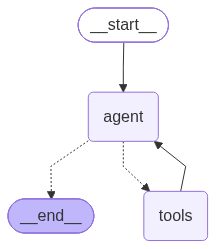

In [74]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.messages import SystemMessage
from IPython.display import Image, display

llm_with_tools = llm.bind_tools(tools)

def agent_node(state: MessagesState):
    """
    Узел агента: получает текущее состояние (список сообщений),
    передает его в LLM и возвращает ответ модели (который может содержать tool_calls).
    """

    messages = [SystemMessage(content=system_prompt)] + state["messages"]
    response = llm_with_tools.invoke(messages)

    return {"messages": [response]}

builder = StateGraph(MessagesState)

builder.add_node("agent", agent_node)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "agent")

builder.add_conditional_edges(
    "agent",
    tools_condition,
    {"tools": "tools", END: END}
)

builder.add_edge("tools", "agent")

graph = builder.compile()

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Альтернативный вывод в текстовом виде:")
    print(graph.get_graph().draw_mermaid())

### 2.2 - 2.3 Промпт для Оркестратора и создание субагентов (15 баллов)

**Задание:**
1. Разделите ваши 3 инструмента между двумя субагентами (например, Агент-Аналитик и Агент-Информатор).
2. Напишите системный промпт для Оркестратора, описывающий компетенции каждого субагента и правила маршрутизации.
3. Реализуйте субагентов как отдельные узлы в графе.
4. Оркестратор должен анализировать запрос пользователя и направлять его нужному субагенту.

**Подсказки по промпту Оркестратора:**
- Четко опишите, что умеет каждый субагент. Чем точнее описание - тем лучше маршрутизация.
- Укажите, что делать, если запрос не подходит ни одному субагенту.
- Попросите Оркестратора объяснять свое решение о маршрутизации.

**Подсказки по архитектуре:**
- Каждый субагент - это отдельная функция-узел в графе, которая вызывает своего LLM с набором инструментов.
- Оркестратор может быть реализован как узел с `conditional_edges`, которые смотрят на решение LLM.
- Для передачи контекста между агентами используйте поле `messages` в состоянии графа.
- Можно добавить кастомные поля в состояние (например, `current_agent: str`) для отслеживания маршрута.

Пример структуры мультиагентного графа:
```python
class AgentState(MessagesState):
    current_agent: str  # какой агент сейчас работает

def orchestrator_node(state):
    # LLM решает, кому делегировать
    ...

def analyst_agent_node(state):
    # Субагент с инструментами анализа
    ...

def info_agent_node(state):
    # Субагент с инструментами получения информации
    ...
```


/tmp/ipykernel_2298/3905655335.py:62: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  analyst_graph = create_react_agent(model=llm, tools=analyst_tools, prompt=analyst_prompt)
/tmp/ipykernel_2298/3905655335.py:63: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  informant_graph = create_react_agent(model=llm, tools=informant_tools, prompt=informant_prompt)


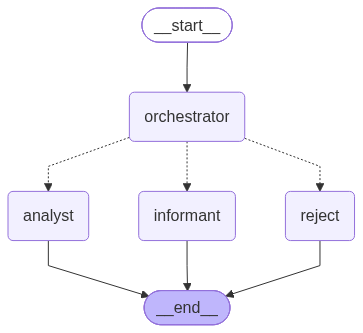

Граф визуализирован выше.


In [75]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import create_react_agent
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from langchain_core.tools import tool
from typing import Literal
from IPython.display import Image, display

analyst_tools = [calculate_compound_interest]

informant_tools = [get_weather, get_currency_rate]

@tool
def transfer_to_analyst(query: str) -> str:
    """Передаёт запрос Агенту-Аналитику.
    Используй, когда запрос связан с финансовыми расчётами: сложные проценты, вклады, кредиты, инвестиции, доходность."""
    return "Запрос передан Агенту-Аналитику"

@tool
def transfer_to_informant(query: str) -> str:
    """Передаёт запрос Агенту-Информатору.
    Используй, когда запрос связан с получением актуальных данных: погода в городе, курс валют, справочная информация."""
    return "Запрос передан Агенту-Информатору"

orchestrator_prompt = """Вы — Оркестратор мультиагентной системы. Ваша задача — проанализировать запрос пользователя и направить его нужному субагенту, вызвав соответствующий инструмент маршрутизации.

У вас есть два субагента:
1. Агент-Аналитик (transfer_to_analyst): эксперт по финансовым расчётам. Умеет считать сложные проценты по вкладам и кредитам.
2. Агент-Информатор (transfer_to_informant): специалист по актуальным данным. Умеет получать погоду в городах и курсы валют.

Правила маршрутизации:
- Запрос о расчётах, процентах, вкладах, кредитах → вызовите transfer_to_analyst
- Запрос о погоде, курсах валют, внешних данных → вызовите transfer_to_informant
- Если запрос содержит задачи для обоих → вызовите transfer_to_analyst (он приоритетнее)
- Если запрос НЕ подходит ни одному (стихи, рецепты, общие вопросы, политика) → НЕ вызывайте инструменты, а просто вежливо откажите текстом.

Всегда объясняйте своё решение о маршрутизации.
"""

llm_orchestrator = llm.bind_tools([transfer_to_analyst, transfer_to_informant])

def orchestrator_node(state: MessagesState):
    """Оркестратор анализирует запрос и решает, кому делегировать."""
    messages = [SystemMessage(content=orchestrator_prompt)] + state["messages"]
    response = llm_orchestrator.invoke(messages)
    return {"messages": [response]}

def route_after_orchestrator(state: MessagesState) -> Literal["analyst", "informant", "reject"]:
    """Смотрит на tool_calls оркестратора и направляет в нужный узел."""
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        tool_name = last_message.tool_calls[0]["name"]
        if tool_name == "transfer_to_analyst":
            return "analyst"
        elif tool_name == "transfer_to_informant":
            return "informant"
    return "reject"


analyst_prompt = "Вы — Агент-Аналитик, эксперт по финансовым расчётам. Используйте инструмент calculate_compound_interest для точных вычислений. Отвечайте на русском языке, кратко и по делу."
informant_prompt = "Вы — Агент-Информатор, специалист по актуальным данным. Используйте инструменты get_weather и get_currency_rate для получения информации. Отвечайте на русском языке, кратко и по делу."

analyst_graph = create_react_agent(model=llm, tools=analyst_tools, prompt=analyst_prompt)
informant_graph = create_react_agent(model=llm, tools=informant_tools, prompt=informant_prompt)

def analyst_node(state: MessagesState):
    """Субагент-Аналитик: выполняет финансовые расчёты."""
    user_messages = [m for m in state["messages"] if isinstance(m, HumanMessage)]
    if user_messages:
        result = analyst_graph.invoke({"messages": [user_messages[0]]})
        return {"messages": [result["messages"][-1]]}
    return {"messages": [AIMessage(content="Не удалось извлечь запрос.")]}

def informant_node(state: MessagesState):
    """Субагент-Информатор: получает погоду и курсы валют."""
    user_messages = [m for m in state["messages"] if isinstance(m, HumanMessage)]
    if user_messages:
        result = informant_graph.invoke({"messages": [user_messages[0]]})
        return {"messages": [result["messages"][-1]]}
    return {"messages": [AIMessage(content="Не удалось извлечь запрос.")]}

def reject_node(state: MessagesState):
    """Узел отказа: запрос вне компетенции системы."""
    return {"messages": [AIMessage(
        content="Извините, наша мультиагентная система может помочь только с финансовыми расчётами, погодой и курсами валют. Пожалуйста, переформулируйте ваш запрос."
    )]}

builder = StateGraph(MessagesState)

builder.add_node("orchestrator", orchestrator_node)
builder.add_node("analyst", analyst_node)
builder.add_node("informant", informant_node)
builder.add_node("reject", reject_node)

builder.add_edge(START, "orchestrator")

builder.add_conditional_edges(
    "orchestrator",
    route_after_orchestrator,
    {"analyst": "analyst", "informant": "informant", "reject": "reject"}
)

builder.add_edge("analyst", END)
builder.add_edge("informant", END)
builder.add_edge("reject", END)

multi_agent_graph = builder.compile()

try:
    display(Image(multi_agent_graph.get_graph().draw_mermaid_png()))
    print("Граф визуализирован выше.")
except Exception as e:
    print(f"Не удалось отрисовать PNG: {e}")
    print("Текстовая схема графа:")
    print(multi_agent_graph.get_graph().draw_mermaid())

In [76]:
from langchain_core.messages import HumanMessage

def test_multi_agent(test_name: str, query: str):
    print(f"{test_name}")
    print(f"Запрос: \"{query}\"")

    try:
        result = multi_agent_graph.invoke(
            {"messages": [HumanMessage(content=query)]},
            config={"recursion_limit": 15}
        )

        final = result["messages"][-1]
        print(f"Финальный ответ:\n   {final.content}")

        print(f"Всего сообщений в цепочке: {len(result['messages'])}")
    except Exception as e:
        print(f"Ошибка: {e}")


test_multi_agent(
    "Тест 1: Агент-Аналитик (финансы)",
    "Сколько я получу, если положу 200 000 рублей под 14% годовых с ежемесячной капитализацией на 5 лет?"
)


test_multi_agent(
    "Тест 2: Агент-Информатор (погода + валюта)",
    "Какая сейчас погода в Казани и какой курс евро?"
)

test_multi_agent(
    "Тест 3: Отказ",
    "Расскажи мне анекдот про попугая и напиши рецепт лазаньи."
)

Тест 1: Агент-Аналитик (финансы)
Запрос: "Сколько я получу, если положу 200 000 рублей под 14% годовых с ежемесячной капитализацией на 5 лет?"
Финальный ответ:
   Вы получите 401121.96 рублей, если положите 200 000 рублей под 14% годовых с ежемесячной капитализацией на 5 лет.
Всего сообщений в цепочке: 3
Тест 2: Агент-Информатор (погода + валюта)
Запрос: "Какая сейчас погода в Казани и какой курс евро?"
Финальный ответ:
   Сейчас в Казани солнечно и +25°C. Курс евро к рублю составляет 89.07 рублей.
Всего сообщений в цепочке: 3
Тест 3: Отказ
Запрос: "Расскажи мне анекдот про попугая и напиши рецепт лазаньи."
Финальный ответ:
   Извините, наша мультиагентная система может помочь только с финансовыми расчётами, погодой и курсами валют. Пожалуйста, переформулируйте ваш запрос.
Всего сообщений в цепочке: 3


### 2.4 Human-in-the-loop (Безопасность) (10 баллов)

**Задание:**
1. Добавьте инструмент `send_report_to_management` (может просто печатать текст или сохранять в файл).
2. Настройте граф так, чтобы перед вызовом этого инструмента выполнение приостанавливалось и ожидало ручного подтверждения.

**Подсказки:**
- В LangGraph для паузы используется параметр `interrupt_before=["tools"]` при компиляции графа.
- Для сохранения состояния во время паузы нужен `checkpointer`. Используйте `MemorySaver` для тестирования.
- Каждый запуск графа должен иметь уникальный `thread_id` в `config` - это идентификатор сессии.
- Чтобы возобновить выполнение, вызовите граф повторно с тем же `thread_id` и `None` в качестве входных данных.
- Используйте `graph.get_state(config)` чтобы проверить текущее состояние и убедиться, что граф на паузе.

Пример паузы и возобновления:
```python
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
graph = builder.compile(checkpointer=memory, interrupt_before=["tools"])

config = {"configurable": {"thread_id": "session-1"}}

# Первый запуск - граф остановится перед вызовом инструмента
result = graph.invoke({"messages": [("user", "запрос")]}, config)

# Проверяем состояние
state = graph.get_state(config)
print("Граф на паузе:", state.next)

# Возобновляем выполнение (подтверждение)
final_result = graph.invoke(None, config)
```


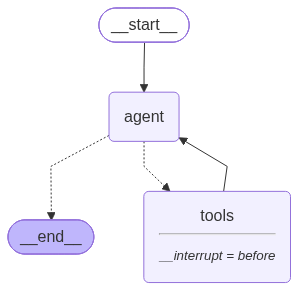

In [77]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_core.tools import tool
from IPython.display import Image, display
import os
from datetime import datetime

@tool
def send_report_to_management(report_text: str) -> str:
    """Отправляет финальный отчет руководству.
    Используй ТОЛЬКО когда пользователь явно просит отправить отчет или составить и отправить сводку для руководства.

    Args:
        report_text: Текст отчета для отправки (должен быть полным и самодостаточным).
    """
    try:

        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f"report_{timestamp}.txt"
        with open(filename, "w", encoding="utf-8") as f:
            f.write(f"Отчет для руководства")
            f.write(f"Дата: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
            f.write(report_text)
        print(f" 'СИСТЕМА' Отчет успешно сохранен в файл: {filename}")
        return f"Отчет отправлен руководству и сохранен в файл {filename}"
    except Exception as e:
        return f"Ошибка: {str(e)}"

hitl_tools = [send_report_to_management]

llm_hitl = llm.bind_tools(hitl_tools)

hitl_system_prompt = """Вы — корпоративный помощник. Ваша задача — помочь пользователю составить отчет для руководства.
Когда пользователь просит отправить отчет, вызовите инструмент send_report_to_management с полным текстом отчета.
Отвечайте на русском языке."""

def hitl_agent_node(state: MessagesState):
    """Узел агента для HITL-графа."""
    messages = [SystemMessage(content=hitl_system_prompt)] + state["messages"]
    response = llm_hitl.invoke(messages)
    return {"messages": [response]}

builder_hitl = StateGraph(MessagesState)
builder_hitl.add_node("agent", hitl_agent_node)
builder_hitl.add_node("tools", ToolNode(hitl_tools))

builder_hitl.add_edge(START, "agent")
builder_hitl.add_conditional_edges(
    "agent",
    tools_condition,
    {"tools": "tools", END: END}
)
builder_hitl.add_edge("tools", "agent")

memory = MemorySaver()

graph_with_hitl = builder_hitl.compile(
    checkpointer=memory,
    interrupt_before=["tools"]
)

try:
    display(Image(graph_with_hitl.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Ошибка: {e}")



### 2.5 Финальное тестирование мультиагентной системы (5 баллов)

Продемонстрируйте полный цикл работы вашей мультиагентной системы.

Задайте сложный запрос, который:
1. Требует делегирования от Оркестратора к субагенту.
2. Заканчивается вызовом инструмента `send_report_to_management`.

Покажите все четыре этапа: запуск, пауза перед отправкой, ручное подтверждение, финальный ответ.

**Подсказка:** Выводите промежуточные состояния графа, чтобы было видно, как меняется `state.next` до и после подтверждения.


In [78]:
# TODO: Этап 1 - Запустите граф с комплексным запросом
from langgraph.types import Command

config = {"configurable": {"thread_id": "final-test-hitl-001"}}

complex_query = """
Я подготовил данные по итогам месяца.
Составь краткий финансовый отчет о том, что доходы выросли на 15%,
и отправь этот отчет руководству для утверждения.
"""

print(f"Запрос пользователя:\n   {complex_query.strip()}")

result = graph_with_hitl.invoke(
    {"messages": [{"role": "user", "content": complex_query}]},
    config
)


Запрос пользователя:
   Я подготовил данные по итогам месяца. 
Составь краткий финансовый отчет о том, что доходы выросли на 15%, 
и отправь этот отчет руководству для утверждения.


In [79]:
# TODO: Этап 2 - Проверьте, что граф на паузе
state = graph_with_hitl.get_state(config)


print(f"Следующий шаг (state.next): {state.next}")
print(f"Граф приостановлен: {len(state.next) > 0}")

if state.next:
    print("Анализ последнего сообщения агента:")
    last_msg = state.values["messages"][-1]
    if hasattr(last_msg, 'tool_calls') and last_msg.tool_calls:
        print(f"Агент хочет вызвать инструмент: '{last_msg.tool_calls[0]['name']}'")
        print(f"Аргументы: {last_msg.tool_calls[0]['args']}")
    else:
        print(f"Текст: {last_msg.content}")


Следующий шаг (state.next): ('tools',)
Граф приостановлен: True
Анализ последнего сообщения агента:
Агент хочет вызвать инструмент: 'send_report_to_management'
Аргументы: {'report_text': 'За отчетный месяц компания достигла значительного роста доходов, который составил 15% по сравнению с предыдущим периодом. Этот положительный тренд указывает на эффективность проводимой финансовой стратегии и позволяет нам оптимистично смотреть на будущие перспективы. Отчет подготовлен для вашего рассмотрения и утверждения.'}


In [80]:
# TODO: Этап 3 - Дайте подтверждение и возобновите выполнение
print("(Отправка команды resume=True в граф)")
try:
    final_result = graph_with_hitl.invoke(
        Command(resume=True),
        config
    )
except Exception:
    final_result = graph_with_hitl.invoke(None, config)


(Отправка команды resume=True в граф)
 'СИСТЕМА' Отчет успешно сохранен в файл: report_20260726_174532.txt


In [81]:
# TODO: Этап 4 - Выведите финальный ответ
final_state = graph_with_hitl.get_state(config)
print(f"Следующий шаг после выполнения (state.next): {final_state.next}")
print(f"Граф завершен: {len(final_state.next) == 0}")

print(final_result["messages"][-1].content)


Следующий шаг после выполнения (state.next): ()
Граф завершен: True
Отчет отправлен руководству и сохранен в файл report_20260726_174532.txt


### 2.6 Анализ рисков и идеи по улучшению мультиагентной системы (10 баллов)

Это задание не оценивается в баллах, но является обязательным. Здесь вы должны проявить системное мышление и осмыслить архитектуру, которую построили.

**Задание:** Напишите развернутый анализ (минимум 400 слов) в ячейке ниже, ответив на следующие вопросы:

**Риски мультиагентной архитектуры:**
- Что произойдет, если Оркестратор неправильно определит нужного субагента? Как часто это может происходить и почему?
- Как растет стоимость и задержка при добавлении новых субагентов? Когда мультиагентность становится избыточной?
- Насколько надежен механизм Human-in-the-loop? Что если человек нажмет "подтвердить" не глядя?
- Какие риски несет общее состояние (`messages`) между агентами? Может ли один субагент "запутать" другого?

**Гипотезы по улучшению:**
- Как можно улучшить качество маршрутизации Оркестратора? Например, добавить классификатор намерений (intent classifier) перед Оркестратором.
- Как добавить долгосрочную память агентам? Например, сохранять важные факты из разговоров в векторную базу данных.
- Как реализовать параллельное выполнение субагентов, если запрос требует работы нескольких из них одновременно?
- Как можно автоматически оценивать качество ответов агентов (LLM-as-a-judge)?

**Идеи по расширению:**
- Какие новые субагенты и инструменты сделали бы вашу систему значительно полезнее?
- Как бы вы развернули эту систему в продакшене? Какую инфраструктуру выбрали бы?
- Как реализовать мониторинг и трассировку работы агентов в реальном времени (например, через Arize Phoenix или LangSmith)?
- Как обеспечить безопасность системы от prompt injection атак, когда злоумышленник пытается через пользовательский запрос изменить поведение агента?


**Ваш анализ:**
1. Ошибки маршрутизации Оркестратора. Если Оркестратор неверно определит субагента, запрос уйдёт не туда, и пользователь получит либо нерелевантный ответ, либо вежливый отказ.

2. Рост стоимости и задержки. Каждый дополнительный субагент добавляет как минимум один LLM-вызов (Оркестратор) + один вызов самого субагента. При 5 субагентах и сложном запросе можно легко получить 7-10 вызовов LLM, что увеличивает latency до 10-30 секунд и стоимость в 5-10 раз по сравнению с монолитным агентом. Мультиагентность становится избыточной, когда задачи субагентов сильно пересекаются или когда один агент способен покрыть все сценарии.

3. Ненадёжность Human-in-the-loop. Механизм HITL уязвим к «усталости от подтверждений» : если пользователь часто нажимает «Подтвердить» не глядя, система теряет смысл безопасности. Решение — показывать не просто факт вызова инструмента, а его последствия .

4. Риски общего состояния . Все субагенты видят общую историю сообщений. Если Агент-Аналитик оставит в state «шумные» промежуточные рассуждения, Агент-Информатор может их интерпретировать как часть запроса и дать сбой. Решение — изолировать контекст: передавать субагентам только финальный запрос пользователя, а не весь state["messages"].

Гипотезы по улучшению
1. Классификатор намерений перед Оркестратором. Вместо того чтобы полагаться на LLM-рассуждения, можно поставить лёгкий intent-классификатор на входе. Он за 5-10 мс определит категорию запроса и жёстко направит его в нужный субагент, убрав галлюцинации маршрутизации.

2. Параллельное выполнение . Если запрос требует работы нескольких субагентов , Оркестратор может возвращать список tool_calls, а LangGraph — выполнять их параллельно через Send API, а затем агрегировать результаты в финальном узле-агрегаторе.

3. LLM-as-a-judge для авто-оценки. Вторая LLM оценивает ответы первой по критериям: фактологическая точность, полнота, следование инструкциям. Это позволяет автоматически собирать метрики качества без ручной разметки.

Идеи по расширению

1. Новые субагенты: Агент-исследователь , Агент-визуализатор , Агент-безопасник .

2. Мониторинг и трассировка: Интеграция с LangSmith или Arize Phoenix. Это позволяет видеть latency, token usage и ошибки в реальном времени.

3. Защита от prompt injection: Многоуровневая защита:входной фильтр

---
**Поздравляем с завершением домашнего задания!**

Вы прошли путь от базового ReAct агента до мультиагентной системы с защитой и человеком в контуре. Это фундамент для построения реальных продакшен-систем на базе LLM.